## TASK 1 — Data Loading & Exploratory Analysis

### Step 1: Load Dataset and Initial Inspection

In [11]:
import pandas as pd

In [12]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [13]:
print("Shape of dataset:", df.shape)

Shape of dataset: (7043, 21)


In [14]:
print("\nColumn Data Types:\n")
print(df.dtypes)


Column Data Types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [15]:
print("\nFirst 10 Rows:\n")
df.head(10)


First 10 Rows:



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### Step 2: Target column & class imbalance

In [16]:
# Check unique values in target column
print("Unique values in Churn column:")
print(df["Churn"].unique())

Unique values in Churn column:
['No' 'Yes']


In [17]:
# Count of each class
print("\nChurn Value Counts:")
print(df["Churn"].value_counts())


Churn Value Counts:
No     5174
Yes    1869
Name: Churn, dtype: int64


In [18]:
# Percentage distribution
print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


Churn Percentage:
No     73.463013
Yes    26.536987
Name: Churn, dtype: float64


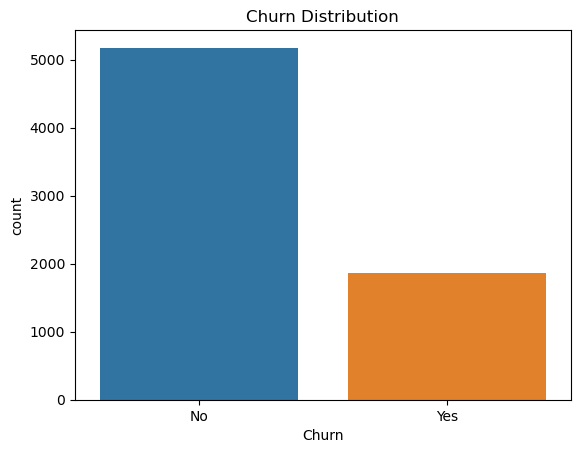

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Countplot
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

### Step 3: Missing Values Analysis

In [20]:
# Check missing values
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [21]:
# Check for blank spaces
print("\nChecking for blank values in TotalCharges:")
print((df["TotalCharges"] == " ").sum())


Checking for blank values in TotalCharges:
11


In [22]:
# Replace blank spaces with NaN
import numpy as np

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Now check again
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [23]:
# Drop missing rows
df = df.dropna()

# Final check
print("\nFinal shape after dropping missing values:", df.shape)


Final shape after dropping missing values: (7032, 21)


### Step 4: Summary Statistics of Numerical Features

In [24]:
# Summary statistics
print("Summary Statistics:\n")
print(df.describe())

Summary Statistics:

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7032.000000  7032.000000     7032.000000   7032.000000
mean        0.162400    32.421786       64.798208   2283.300441
std         0.368844    24.545260       30.085974   2266.771362
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.587500    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.862500   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


In [25]:
print("\nMedian Values:\n")
print(df.median(numeric_only=True))


Median Values:

SeniorCitizen        0.000
tenure              29.000
MonthlyCharges      70.350
TotalCharges      1397.475
dtype: float64


### Step 5: Correlation Heatmap

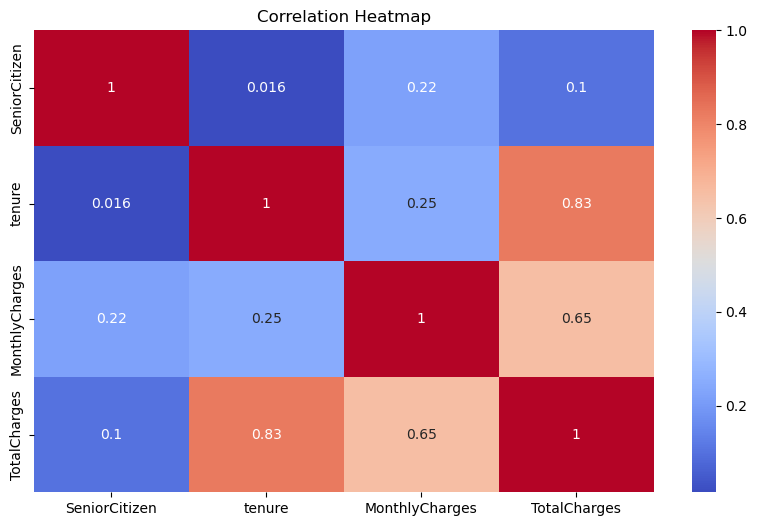

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## TASK 2 — Data Preprocessing & Feature Engineering

### Step 1: Convert TotalCharges to Numeric

In [27]:
# Check data type before conversion
print("Before Conversion:\n")
print(df["TotalCharges"].dtype)

# Convert to numeric (safe conversion)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Check again
print("\nAfter Conversion:\n")
print(df["TotalCharges"].dtype)

Before Conversion:

float64

After Conversion:

float64


### Step 2: Encoding Categorical Variables (One-Hot Encoding)

In [28]:
# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:\n", categorical_cols)

Categorical Columns:
 Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [29]:
# Remove target column
categorical_cols = categorical_cols.drop("Churn")

In [30]:
# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df.shape)

Shape after encoding: (7032, 7062)


In [31]:
# Convert target column (Yes/No → 1/0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


### Step 3: Feature Engineering

In [32]:
# Feature 1: Charges per month
df["ChargesPerMonth"] = df["TotalCharges"] / (df["tenure"] + 1)

In [33]:
# Feature 2: Senior citizen with no tech support
df["SeniorWithNoSupport"] = ((df["SeniorCitizen"] == 1) & 
                            (df["TechSupport_Yes"] == 0)).astype(int)

In [34]:
print(df[["ChargesPerMonth", "SeniorWithNoSupport"]].head())

   ChargesPerMonth  SeniorWithNoSupport
0        14.925000                    0
1        53.985714                    0
2        36.050000                    0
3        40.016304                    0
4        50.550000                    0


### Step 4: Feature Scaling using StandardScaler

In [35]:
# Separate X and y
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [36]:
# Get numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:\n", num_cols)

Numerical Columns:
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ChargesPerMonth'],
      dtype='object')


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale only numerical columns
X[num_cols] = scaler.fit_transform(X[num_cols])

print("Scaling done successfully!")

Scaling done successfully!


### Step 5: Train-Test Split (80/20 with Stratification)

In [38]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5625, 7063)
Testing set shape: (1407, 7063)


## TASK 3 — Model Training & Comparison

### Step 1: Logistic Regression Model

In [39]:
from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Step 2: Evaluation of Logistic Regression

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions already done: y_pred_log

# Probabilities (needed for ROC-AUC later)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Metrics
print("Logistic Regression Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Logistic Regression Performance:

Accuracy: 0.8002842928216063
Precision: 0.6422018348623854
Recall: 0.5614973262032086
F1 Score: 0.5991440798858773
ROC-AUC: 0.8384760134802843


### Step 3: Random Forest Classifier

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Step 4: Evaluation of Random Forest

In [42]:
# Random Forest Performance
print("Random Forest Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Performance:

Accuracy: 0.7938877043354655
Precision: 0.6448275862068965
Recall: 0.5
F1 Score: 0.5632530120481927
ROC-AUC: 0.8295435132602721


### Step 5: Gradient Boosting Classifier

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

# Create model
gb_model = GradientBoostingClassifier(random_state=42)

# Train model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)

# Probabilities
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


### Step 6: Evaluation of Gradient Boosting

In [44]:
# Gradient Boosting Performance
print("Gradient Boosting Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Gradient Boosting Performance:

Accuracy: 0.798862828713575
Precision: 0.6585365853658537
Recall: 0.5053475935828877
F1 Score: 0.5718608169440241
ROC-AUC: 0.841648073468585


### Step 7: Confusion Matrix Comparison

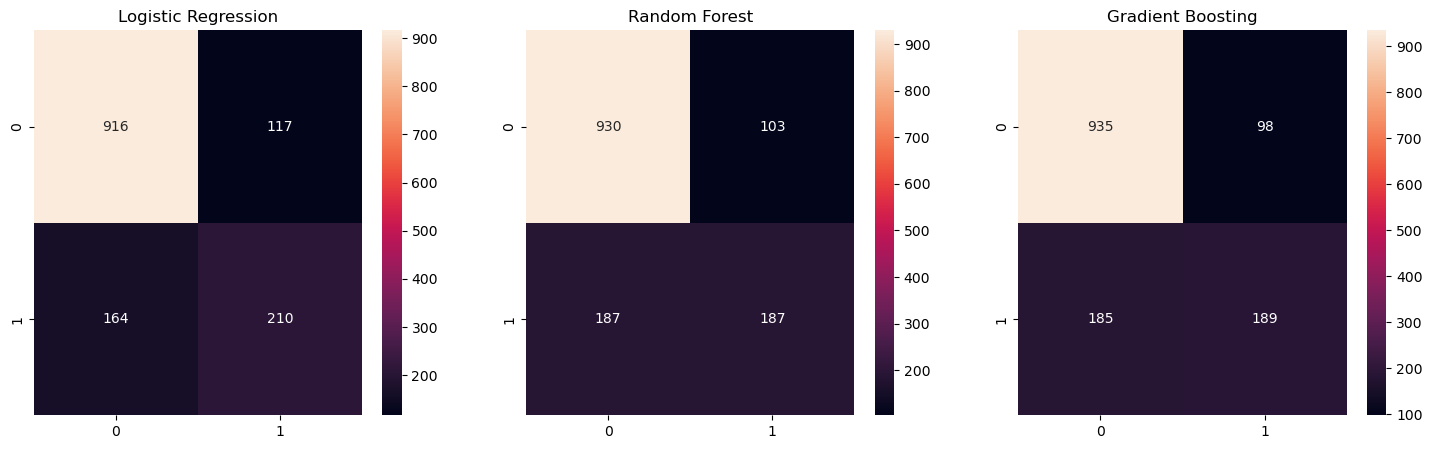

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrices
cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
sns.heatmap(cm_log, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Logistic Regression")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Random Forest")

# Gradient Boosting
sns.heatmap(cm_gb, annot=True, fmt='d', ax=axes[2])
axes[2].set_title("Gradient Boosting")

plt.show()

### Step 8: ROC Curve Comparison

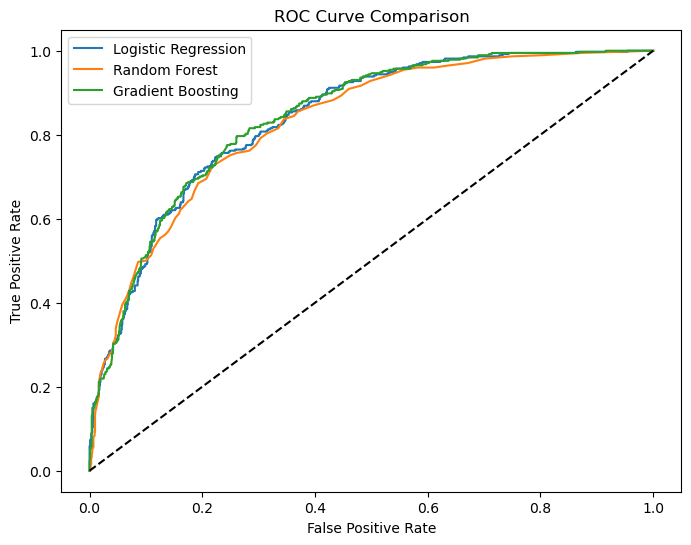

In [ ]:
from sklearn.metrics import roc_curve

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

# Save the figure
plt.savefig("model_comparison.png")

plt.show()

## TASK 4 — Customer Risk Segmentation

### Step 1: Predicted Probabilities from Best Model

In [47]:
# Use best model (Gradient Boosting)
churn_prob = y_prob_gb

print(churn_prob[:10])

[0.03579796 0.54056163 0.02414561 0.16549416 0.08985323 0.4152868
 0.04039829 0.11160196 0.58077955 0.03754094]


### Step 2: Customer Risk Segmentation

In [48]:
# Create a copy of test data for analysis
results_df = X_test.copy()

# Add actual churn and probability
results_df["ActualChurn"] = y_test.values
results_df["ChurnProbability"] = churn_prob

In [49]:
# Function to assign risk tier
def assign_risk(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

# Apply function
results_df["RiskTier"] = results_df["ChurnProbability"].apply(assign_risk)

In [50]:
print(results_df[["ChurnProbability", "RiskTier"]].head())

      ChurnProbability     RiskTier
974           0.035798     Low Risk
619           0.540562  Medium Risk
4289          0.024146     Low Risk
3721          0.165494     Low Risk
4533          0.089853     Low Risk


### Step 3: Count of Customers in Each Risk Tier

In [51]:
# Count customers in each risk tier
risk_counts = results_df["RiskTier"].value_counts()

print("Customer Count by Risk Tier:\n")
print(risk_counts)

Customer Count by Risk Tier:

Low Risk       1002
Medium Risk     311
High Risk        94
Name: RiskTier, dtype: int64


In [52]:
# Percentage distribution
risk_percentage = results_df["RiskTier"].value_counts(normalize=True) * 100

print("\nPercentage Distribution:\n")
print(risk_percentage)


Percentage Distribution:

Low Risk       71.215352
Medium Risk    22.103767
High Risk       6.680881
Name: RiskTier, dtype: float64


### Step 4: Risk Tier Analysis (Charges, Tenure, Contract Distribution)

In [53]:
# Group by risk tier
tier_analysis = results_df.groupby("RiskTier").agg({
    "MonthlyCharges": "mean",
    "tenure": "mean"
})

print("Average Values by Risk Tier:\n")
print(tier_analysis)

Average Values by Risk Tier:

             MonthlyCharges    tenure
RiskTier                             
High Risk          0.550224 -1.185323
Low Risk          -0.198336  0.313077
Medium Risk        0.351799 -0.753983


In [54]:
# Contract columns after encoding
contract_cols = [col for col in results_df.columns if "Contract_" in col]

# Average of each contract type per tier
contract_dist = results_df.groupby("RiskTier")[contract_cols].mean()

print("\nContract Distribution (proportion):\n")
print(contract_dist)


Contract Distribution (proportion):

             Contract_One year  Contract_Two year
RiskTier                                         
High Risk             0.000000           0.000000
Low Risk              0.283433           0.326347
Medium Risk           0.019293           0.000000


### Step 5: Grouped Bar Chart for Risk Tier Comparison

In [55]:
# Reset index for plotting
tier_analysis_reset = tier_analysis.reset_index()

print(tier_analysis_reset)

      RiskTier  MonthlyCharges    tenure
0    High Risk        0.550224 -1.185323
1     Low Risk       -0.198336  0.313077
2  Medium Risk        0.351799 -0.753983


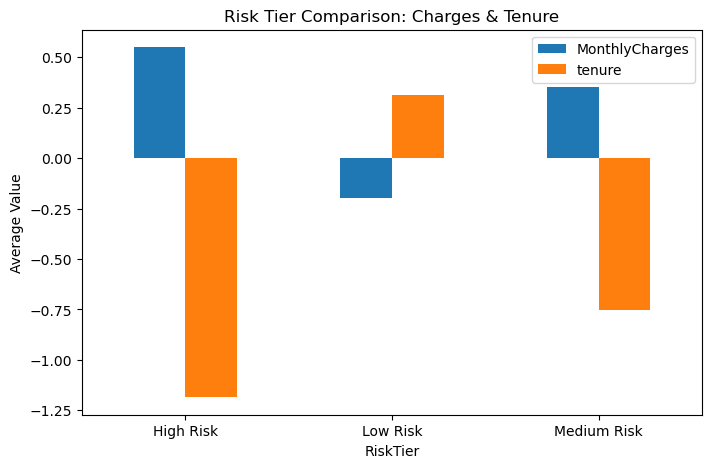

In [56]:
import matplotlib.pyplot as plt

# Set index
tier_analysis_reset.set_index("RiskTier", inplace=True)

# Plot
tier_analysis_reset.plot(kind="bar", figsize=(8, 5))

plt.title("Risk Tier Comparison: Charges & Tenure")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

## TASK 5 — Visualizations

### Chart 1: Feature Importance (Top 10 Features)

In [58]:
import os

# Create charts folder if it doesn't exist
os.makedirs("charts", exist_ok=True)

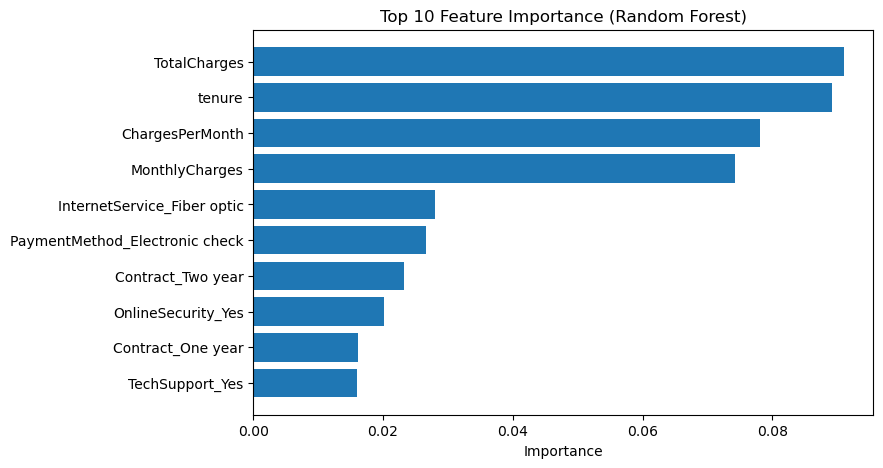

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# Sort and get top 10
top_features = feature_importance_df.sort_values(by="Importance", ascending=False).head(10)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance")

# SAVE IMAGE
plt.savefig("charts/feature_importance.png", bbox_inches='tight')

plt.show()

### Chart 2: Churn Rate by Contract Type

In [61]:
# Reload original dataset for clean visualization
df_original = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [62]:
df_original["Churn"] = df_original["Churn"].map({"Yes": 1, "No": 0})

In [63]:
churn_by_contract = df_original.groupby("Contract")["Churn"].mean()
print(churn_by_contract)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


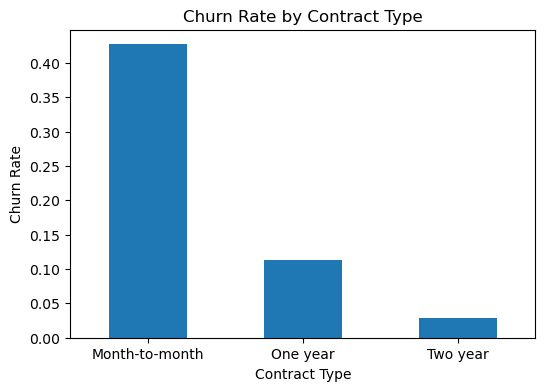

In [65]:
import matplotlib.pyplot as plt

churn_by_contract.plot(kind="bar", figsize=(6, 4))

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.xticks(rotation=0)

# SAVE
plt.savefig("charts/churn_by_contract.png", bbox_inches='tight')

plt.show()

### Chart 3: Tenure Distribution (Churn vs Non-Churn)

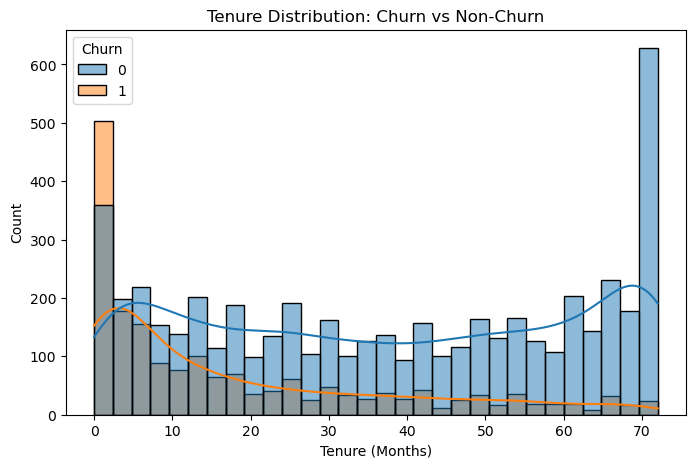

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot distribution
sns.histplot(data=df_original, x="tenure", hue="Churn", bins=30, kde=True)

plt.title("Tenure Distribution: Churn vs Non-Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")

# SAVE
plt.savefig("charts/tenure_distribution.png", bbox_inches='tight')

plt.show()

### Chart 4: Risk Tier Distribution (Pie Chart)

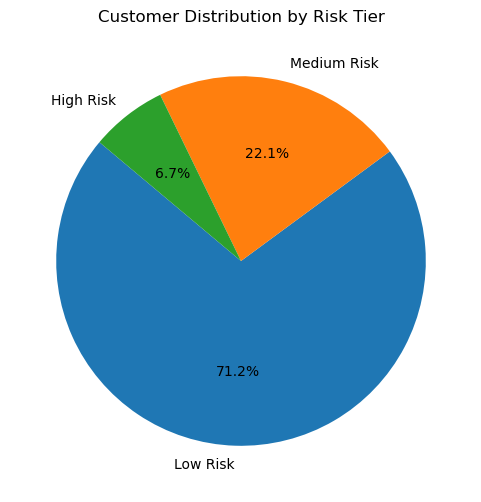

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Pie chart
plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Customer Distribution by Risk Tier")

# SAVE
plt.savefig("charts/risk_tier_pie.png", bbox_inches='tight')

plt.show()

## TASK 6 — Insights & Business Recommendations

**1. Which model performed best and why did you select it?**

The Gradient Boosting model performed the best among the three models, as it achieved the highest ROC-AUC score and maintained a good balance between precision and recall. This makes it more reliable for identifying potential churn customers compared to Logistic Regression and Random Forest.


**2. What are the top 3 factors driving customer churn according to your model?**

The top factors driving customer churn include contract type (especially month-to-month contracts), tenure (shorter customer duration), and monthly charges (higher charges leading to higher churn probability). These features consistently appeared as important across models and visualizations.


**3. What do High Risk customers have in common? (contract type, charges, tenure patterns)**

High-risk customers typically have shorter tenure, higher monthly charges, and are mostly on month-to-month contracts. They also tend to lack long-term commitment and are more likely to leave the service early.


**4. Write 2 specific, actionable business recommendations the company should implement**

1. To reduce churn, the company should focus on converting month-to-month customers into long-term contracts by offering incentives or discounts. 
2. Additionally, providing better onboarding and support for new customers can help increase retention during the early stages.


**5. What are the limitations of your model? What could be improved with more data or time?**

One limitation of this model is that it only uses historical customer data and does not include behavioral or engagement-based features. With more data such as customer usage patterns or service interactions, the model’s predictive performance could be further improved.